In [3]:
!pip install matplotlib-scalebar

In [5]:
from matplotlib_scalebar.scalebar import ScaleBar
print("matplotlib_scalebar instalado correctamente")

matplotlib_scalebar instalado correctamente


Librerías importadas correctamente
 Zonas cargadas: 332
   - Urbanas: 271
   - Rurales: 61
 Temperatura cargada: 7636 registros
 Árboles cargados (TODOS los activos): 234824
 DataFrame creado con 332 zonas
   Columnas: ['OBJECTID', 'NOMBRE', 'ABREVIATURA', 'SUBTIPO_BARRIOVEREDA', 'SHAPE_Length', 'SHAPE_Area', 'Tipo', 'geometry', 'ID', 'Temp_media', 'Temp_max', 'Temp_min', 'num_arboles', 'area_km2', 'densidad_arboles']
Número de zonas por tipo:
Tipo
Urbano    271
Rural      61
Name: count, dtype: int64
Estadísticas de temperatura por tipo de zona:
        count       mean       std        min        max
Tipo                                                    
Rural      61  26.428558  3.976868  20.660379  35.536647
Urbano    271  36.580255  3.301105  26.664715  43.999606
Estadísticas de árboles por tipo de zona:
        count     sum        mean          std  min    max
Tipo                                                      
Rural      61   36627  600.442623  2133.227965    0  13407


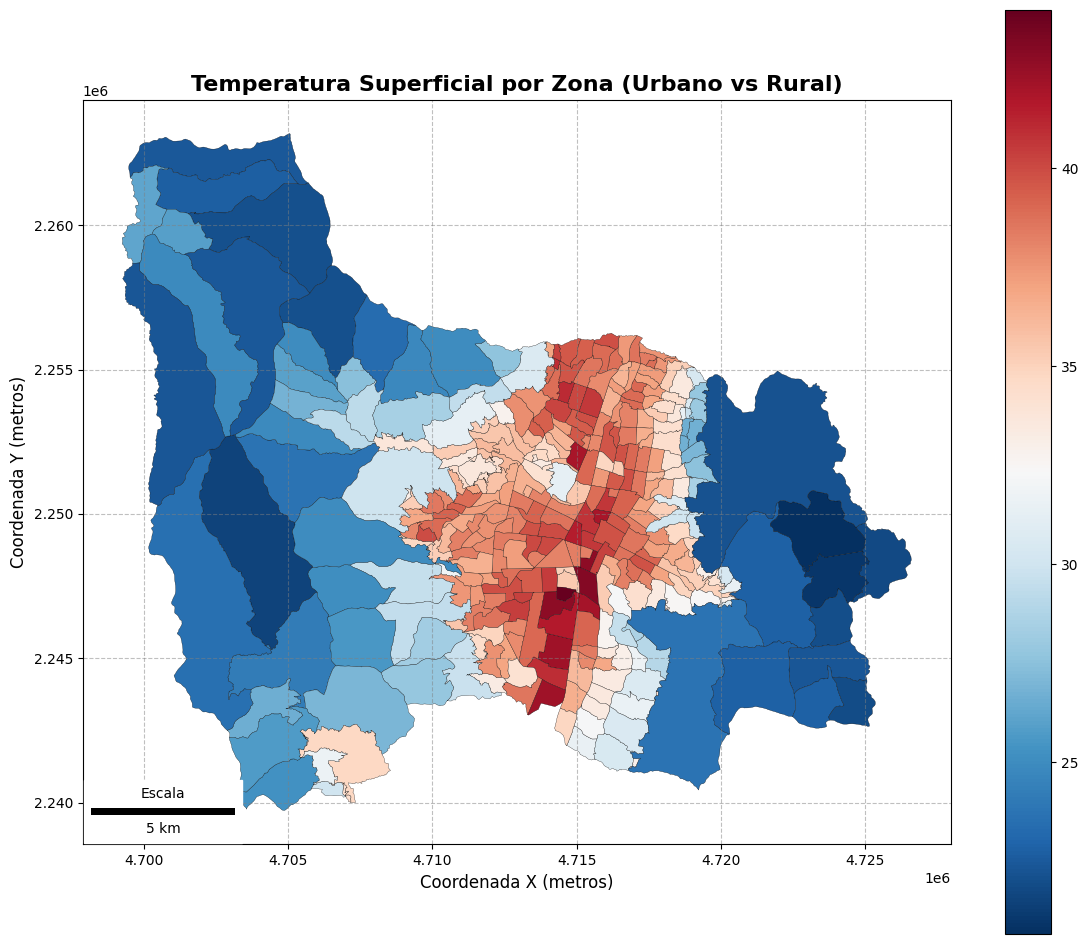

 Mapa de temperatura guardado


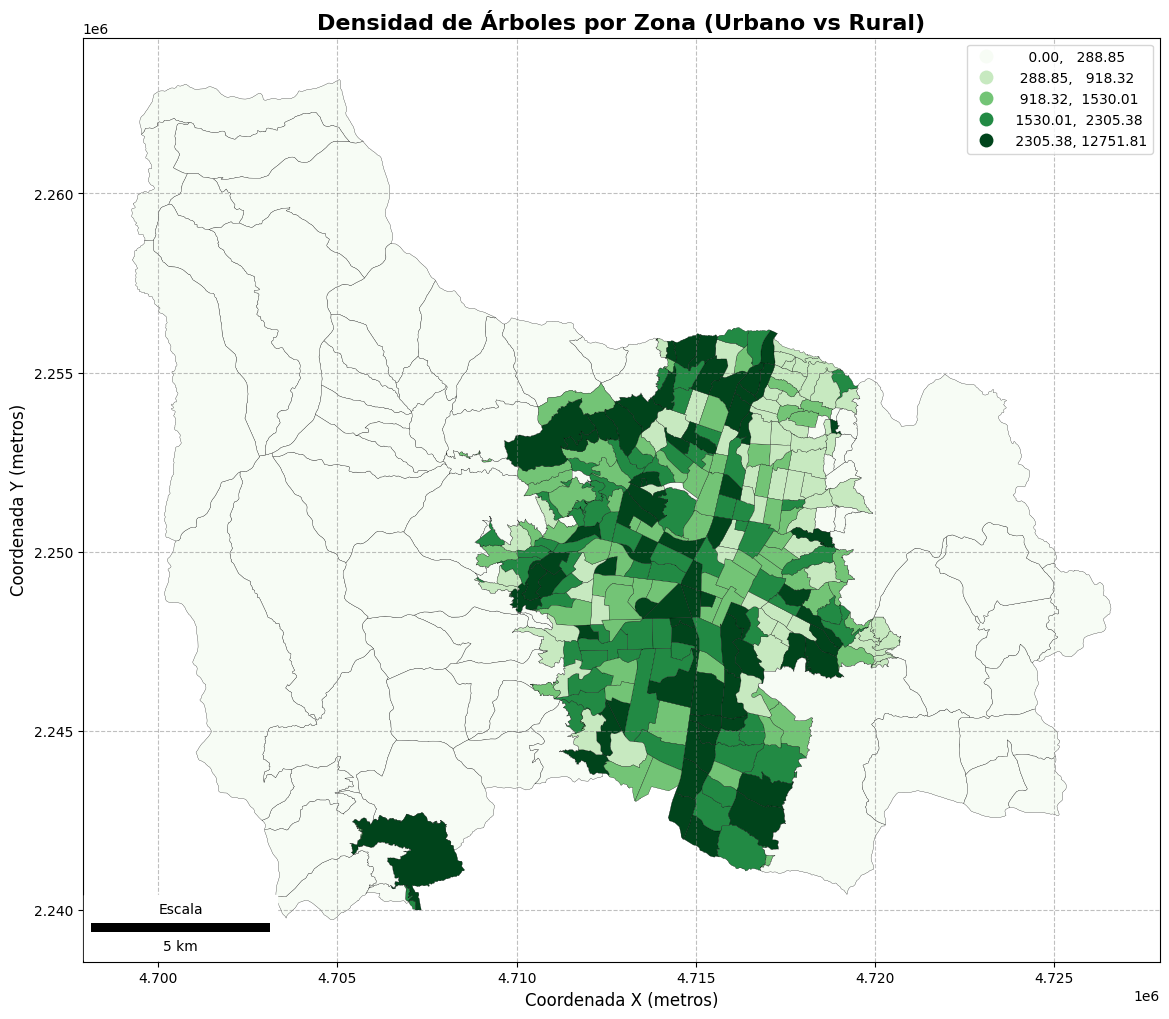

 Mapa de densidad de árboles guardado

Las 5 zonas más calientes:
          NOMBRE   Tipo  Temp_media
          Tenche Urbano   43.999606
Perpetuo Socorro Urbano   43.054830
        Trinidad Urbano   42.810298
     Calle Nueva Urbano   42.785112
      Campo Amor Urbano   42.236049

Las 5 zonas más frías:
      NOMBRE  Tipo  Temp_media
        Mazo Rural   20.660379
Piedra Gorda Rural   21.022060
El Astillero Rural   21.540746
Barro Blanco Rural   21.773034
    El Cerro Rural   21.860646


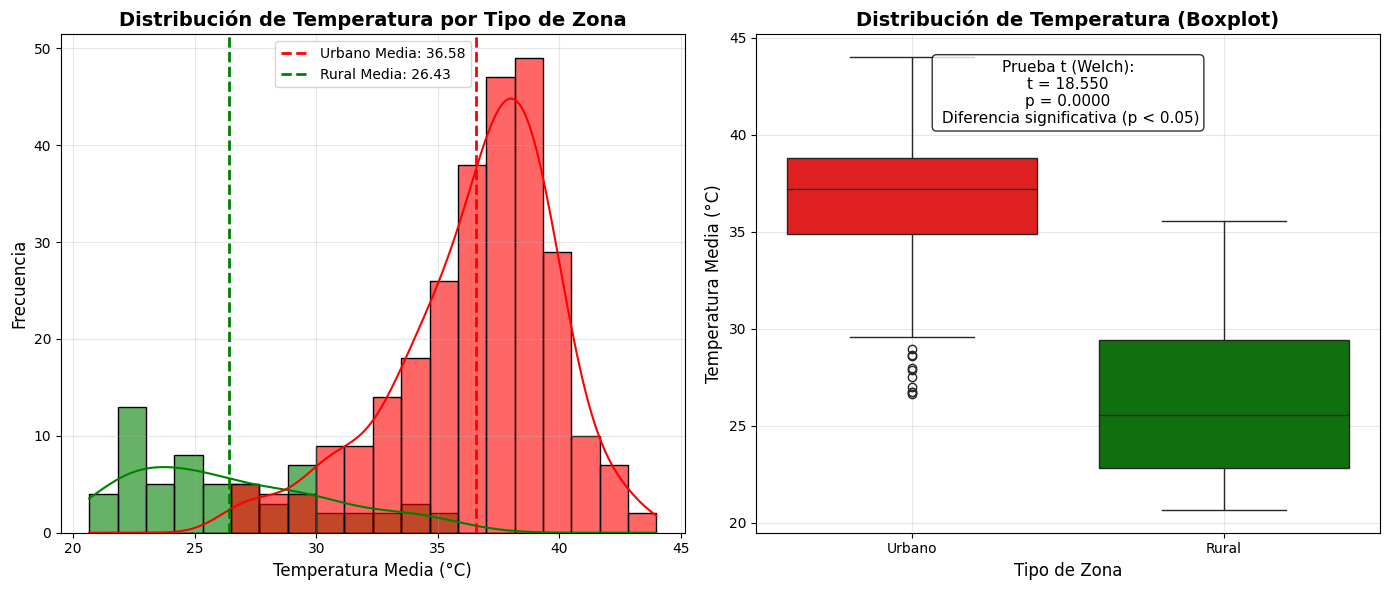

Gráficos guardados

Temperatura media URBANA: 36.58°C
Temperatura media RURAL: 26.43°C
Isla de Calor Urbana: 10.15°C
Correlación temperatura vs densidad de árboles: 0.326

Prueba t (Urbano vs Rural): t = 18.550, p = 0.0000


In [9]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from matplotlib_scalebar.scalebar import ScaleBar
from scipy import stats  # <-- NUEVO: Para la prueba t

print("Librerías importadas correctamente")

# Cargar zonas
ruta_zonas = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Zonas_Medellin.gpkg"
zonas = gpd.read_file(ruta_zonas)

# Cargar temperatura
ruta_temp = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Temperatura_por_zona.csv"
df_temp = pd.read_csv(ruta_temp)

# Cargar árboles (TODOS los activos en Medellín)
ruta_arboles = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Arboles_Activos_Medellin_TODOS.gpkg"
arboles = gpd.read_file(ruta_arboles)

print(f" Zonas cargadas: {len(zonas)}")
print(f"   - Urbanas: {len(zonas[zonas['Tipo'] == 'Urbano'])}")
print(f"   - Rurales: {len(zonas[zonas['Tipo'] == 'Rural'])}")
print(f" Temperatura cargada: {len(df_temp)} registros")
print(f" Árboles cargados (TODOS los activos): {len(arboles)}")

# Dataframe

# Calcular temperatura promedio por zona (ID)
temp_promedio = df_temp.groupby('ID').agg({
    'Temp_media': 'mean',
    'Temp_max': 'mean',
    'Temp_min': 'mean'
}).reset_index()

# Unir temperatura con zonas
zonas_temp = zonas.merge(temp_promedio, left_index=True, right_on='ID', how='left')

# Contar árboles por zona usando unión espacial
arboles_en_zonas = gpd.sjoin(arboles, zonas_temp, how='inner', predicate='within')
conteo_arboles = arboles_en_zonas.groupby('ID').size().reset_index(name='num_arboles')

# Unir conteo de árboles
zonas_temp = zonas_temp.merge(conteo_arboles, on='ID', how='left')
zonas_temp['num_arboles'] = zonas_temp['num_arboles'].fillna(0).astype(int)

# Calcular área y densidad
zonas_temp['area_km2'] = zonas_temp.geometry.area / 1_000_000
zonas_temp['densidad_arboles'] = zonas_temp['num_arboles'] / zonas_temp['area_km2']

print(f" DataFrame creado con {len(zonas_temp)} zonas")
print(f"   Columnas: {zonas_temp.columns.tolist()}")

# Exploración inicial

print("Número de zonas por tipo:")
print(zonas_temp['Tipo'].value_counts())

print("Estadísticas de temperatura por tipo de zona:")
print(zonas_temp.groupby('Tipo')['Temp_media'].agg(['count', 'mean', 'std', 'min', 'max']))

print("Estadísticas de árboles por tipo de zona:")
print(zonas_temp.groupby('Tipo')['num_arboles'].agg(['count', 'sum', 'mean', 'std', 'min', 'max']))

print("Estadísticas de densidad de árboles por tipo de zona:")
print(zonas_temp.groupby('Tipo')['densidad_arboles'].agg(['count', 'mean', 'std', 'min', 'max']))

# Resultados

# Crear carpeta de resultados
ruta_resultados = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados"
if not os.path.exists(ruta_resultados):
    os.makedirs(ruta_resultados)

# Mapa temperatura
fig, ax = plt.subplots(1, figsize=(14, 12))

# Usar legend=True sin legend_kwds complejos
zonas_temp.plot(column='Temp_media', ax=ax, legend=True,
                cmap='RdBu_r', edgecolor='black', linewidth=0.2)

ax.set_title('Temperatura Superficial por Zona (Urbano vs Rural)', fontsize=16, fontweight='bold')

# Grilla con coordenadas
ax.grid(True, linestyle='--', alpha=0.5, color='gray')
ax.set_xlabel('Coordenada X (metros)', fontsize=12)
ax.set_ylabel('Coordenada Y (metros)', fontsize=12)

# Barra de escala
scalebar = ScaleBar(dx=1, units="m", dimension="si-length", 
                    label="Escala", location='lower left', 
                    frameon=True, pad=0.5, font_properties={'size': 10})
ax.add_artist(scalebar)

# Guardar
plt.savefig(os.path.join(ruta_resultados, "Mapa_Temperatura_Completo.png"), dpi=300, bbox_inches='tight')
plt.show()
print(" Mapa de temperatura guardado")

# Mapa densidad de árboles
fig, ax = plt.subplots(1, figsize=(14, 12))

zonas_temp.plot(column='densidad_arboles', ax=ax, legend=True,
                cmap='Greens', edgecolor='black', linewidth=0.2,
                scheme='quantiles', k=5)

ax.set_title('Densidad de Árboles por Zona (Urbano vs Rural)', fontsize=16, fontweight='bold')

# Grilla con coordenadas
ax.grid(True, linestyle='--', alpha=0.5, color='gray')
ax.set_xlabel('Coordenada X (metros)', fontsize=12)
ax.set_ylabel('Coordenada Y (metros)', fontsize=12)

# Barra de escala
scalebar = ScaleBar(dx=1, units="m", dimension="si-length", 
                    label="Escala", location='lower left', 
                    frameon=True, pad=0.5, font_properties={'size': 10})
ax.add_artist(scalebar)

# Guardar
plt.savefig(os.path.join(ruta_resultados, "Mapa_Densidad_Arboles.png"), dpi=300, bbox_inches='tight')
plt.show()
print(" Mapa de densidad de árboles guardado")

# Zonas calientes y frías

columna_nombre = 'NOMBRE' if 'NOMBRE' in zonas_temp.columns else zonas_temp.columns[0]

print("\nLas 5 zonas más calientes:")
top_calientes = zonas_temp.nlargest(5, 'Temp_media')[[columna_nombre, 'Tipo', 'Temp_media']]
print(top_calientes.to_string(index=False))

print("\nLas 5 zonas más frías:")
top_frias = zonas_temp.nsmallest(5, 'Temp_media')[[columna_nombre, 'Tipo', 'Temp_media']]
print(top_frias.to_string(index=False))

# Distribución de la variable

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma
sns.histplot(data=zonas_temp, x='Temp_media', hue='Tipo', kde=True, ax=axes[0], 
             alpha=0.6, palette=['red', 'green'], bins=20)
axes[0].axvline(zonas_temp[zonas_temp['Tipo'] == 'Urbano']['Temp_media'].mean(), 
                color='red', linestyle='--', linewidth=2,
                label=f'Urbano Media: {zonas_temp[zonas_temp["Tipo"] == "Urbano"]["Temp_media"].mean():.2f}')
axes[0].axvline(zonas_temp[zonas_temp['Tipo'] == 'Rural']['Temp_media'].mean(), 
                color='green', linestyle='--', linewidth=2,
                label=f'Rural Media: {zonas_temp[zonas_temp["Tipo"] == "Rural"]["Temp_media"].mean():.2f}')
axes[0].set_title('Distribución de Temperatura por Tipo de Zona', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Temperatura Media (°C)', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)


sns.boxplot(data=zonas_temp, x='Tipo', y='Temp_media', hue='Tipo', ax=axes[1], 
            palette=['red', 'green'], legend=False)
axes[1].set_title('Distribución de Temperatura (Boxplot)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tipo de Zona', fontsize=12)
axes[1].set_ylabel('Temperatura Media (°C)', fontsize=12)
axes[1].grid(True, alpha=0.3)

urbana = zonas_temp[zonas_temp['Tipo'] == 'Urbano']['Temp_media']
rural = zonas_temp[zonas_temp['Tipo'] == 'Rural']['Temp_media']
t_stat, p_value = stats.ttest_ind(urbana, rural, equal_var=False)  


texto = f'Prueba t (Welch):\nt = {t_stat:.3f}\np = {p_value:.4f}'
if p_value < 0.05:
    texto += '\n Diferencia significativa (p < 0.05)'
else:
    texto += '\n Diferencia NO significativa'
    
axes[1].text(0.5, 0.95, texto, transform=axes[1].transAxes,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
             fontsize=11, ha='center', va='top')

plt.tight_layout()
plt.savefig(os.path.join(ruta_resultados, "Histograma_Boxplot_Urbano_Rural_TODOS.png"), dpi=300)
plt.show()
print("Gráficos guardados")

# Isla de calor

media_urbana = zonas_temp[zonas_temp['Tipo'] == 'Urbano']['Temp_media'].mean()
media_rural = zonas_temp[zonas_temp['Tipo'] == 'Rural']['Temp_media'].mean()
diferencia = media_urbana - media_rural

# Correlación (solo si existe la variable)
if 'densidad_arboles' in zonas_temp.columns:
    corr_densidad = zonas_temp['Temp_media'].corr(zonas_temp['densidad_arboles'])
else:
    corr_densidad = np.nan

print(f"\nTemperatura media URBANA: {media_urbana:.2f}°C")
print(f"Temperatura media RURAL: {media_rural:.2f}°C")
print(f"Isla de Calor Urbana: {diferencia:.2f}°C")
print(f"Correlación temperatura vs densidad de árboles: {corr_densidad:.3f}")
print(f"\nPrueba t (Urbano vs Rural): t = {t_stat:.3f}, p = {p_value:.4f}")
